# Peak Sampling: Evidence for a Bimodal-Scale Gaussian

This notebook estimates the Bayesian evidence (**ln Z**) for a **bimodal-scale Gaussian** benchmark — two isotropic Gaussians sharing the same centre but with very different widths — using:

- **Dynesty** for posterior sampling via nested sampling
- **MorphZ** for evidence estimation from the posterior samples

## 1. What We Are Computing

Parameters $\theta \in \mathbb{R}^D$ live in a uniform prior box $\left[-\tfrac{1}{2},\, \tfrac{1}{2}\right]^D$.

**Prior:**
$$
p(\theta) = 1, \quad \theta \in \left[-\tfrac{1}{2},\, \tfrac{1}{2}\right]^D
$$

**Likelihood** — sum of two isotropic Gaussians centred at the origin with widths $v = 0.1$ (broad) and $u = 0.01$ (narrow):
$$
\mathcal{L}(\theta)
  = \mathcal{N}(\theta;\, \mathbf{0},\, v^2 I_D)
  + \mathcal{N}(\theta;\, \mathbf{0},\, u^2 I_D)
$$

**Challenge:** The narrow component ($u = 0.01$) dominates the posterior peak but contributes negligible volume. A sampler must adequately explore both scales to yield an accurate evidence estimate.

**Evidence:**
$$
Z = \int \mathcal{L}(\theta)\, p(\theta)\, \mathrm{d}\theta
$$

Because both Gaussians are almost entirely contained within the prior box (their widths are much smaller than $\tfrac{1}{2}$), each integrates to 1, giving the closed-form result:
$$
\ln Z = \ln 2 \approx 0.6931
$$

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import morphZ
import corner
import numpy as np
import dynesty
from dynesty import utils as dyfunc

## 3. Numerical Helpers

Summing log-probabilities requires numerically stable log-sum-exp routines to avoid floating-point overflow or underflow.

- `log_plus(x, y)` computes $\log(e^x + e^y)$ stably by factoring out the larger term:
$$
\log(e^x + e^y) = \max(x,y) + \log\!\left(1 + e^{\min(x,y) - \max(x,y)}\right)
$$
- `log_sum(vec)` extends this sequentially to a vector of log-probabilities.

In [2]:

def log_plus(x,y):
    
    if x > y:
      summ = x + np.log(1+np.exp(y-x))
    else:
        summ = y + np.log(1+np.exp(x-y))
    return summ

def log_sum(vec): 
    r = -np.Inf
    for i in range(len(vec)):
       #print('element:',vec[i])
       r =log_plus(r, vec[i])
       #print(r)
    return r



## 4. Model Definition

We define the **log-likelihood**, **log-prior**, and **log-posterior** as scalar functions of a parameter vector $\theta \in \mathbb{R}^D$.

**Log-likelihood** — log of the sum of two isotropic $D$-dimensional Gaussians:
$$
\ln \mathcal{L}(\theta)
  = \log\!\Bigl[
      \mathcal{N}(\theta;\, \mathbf{0},\, v^2 I_D)
      + \mathcal{N}(\theta;\, \mathbf{0},\, u^2 I_D)
    \Bigr]
$$

with $v = 0.1$ and $u = 0.01$. The outer `log` is evaluated via `log_plus` to avoid numerical underflow.

**Log-prior** — uniform box:
$$
\ln p(\theta)
  = \begin{cases}
      0 & \theta \in [-0.5,\, 0.5]^D \\
      -\infty & \text{otherwise}
    \end{cases}
$$

**Log-posterior:**
$$
\ln \pi(\theta) = \ln \mathcal{L}(\theta) + \ln p(\theta)
$$

In [3]:

def lnlikefn(x):
    x = np.asarray(x)
    u, v = 0.01, 0.1
    n = x.shape[-1]

    x1 = np.sum(-x**2 / (2 * v**2), axis=-1)
    x1 -= n * np.log(np.sqrt(2 * np.pi) * v)

    x2 = np.sum(-x**2 / (2 * u**2), axis=-1)
    x2 -= n * np.log(np.sqrt(2 * np.pi) * u)

    # Stable vectorized equivalent of log(exp(x1) + exp(x2))
    return np.logaddexp(x1, x2)


def lnpriorfn(x):
    x = np.asarray(x)
    outside = np.any((x < -0.5) | (x > 0.5), axis=-1)
    return np.where(outside, -np.inf, 0.0)
def lnprobfn(x):
    return lnlikefn(x) + lnpriorfn(x)



## 5. Run Dynesty Nested Sampler

We use **Dynesty** to draw posterior samples via nested sampling with $n_\text{live} = 25D$ live points.

The **prior transform** maps the unit hypercube $[0,1]^D$ uniformly to $[-0.5,\, 0.5]^D$:
$$
\theta_i = u_i - 0.5, \qquad u_i \sim \mathrm{Uniform}(0, 1)
$$

After the run, Dynesty returns importance-weighted samples $\{(\theta^{(k)},\, w^{(k)})\}$. We call `resample_equal` to draw an unweighted posterior sample for use with MorphZ.

In [4]:

ndim = 15  # number of parameters/dimensions
# nlive = 20 * ndim  # number of live points (analogous to nwalkers)
nlive = 2*25 * ndim  # number of live points (analogous to nwalkers)



# Define the prior transform: maps a unit cube (0,1) to the prior volume.
# For a uniform prior between -0.5 and 0.5 for each parameter:
def prior_transform(u):
    # u is a 1D array of ndim values in [0, 1]
    return -0.5 + u  # scales u to [-0.5, 0.5]

# Create the nested sampler instance.

# Run the nested sampling.
# Note: print_progress=True shows the progress.
NN = 1

log_z_NS = np.zeros(NN)
log_z_NS_err = np.zeros(NN)

for i in range(NN):
    sampler = dynesty.NestedSampler(lnlikefn, prior_transform, ndim, nlive=nlive)
    sampler.run_nested(dlogz=1e-6, maxiter=2000000,print_progress=True)
    res = sampler.results
    log_z_NS[i] = res.logz[-1]
    log_z_NS_err[i] = res.logzerr[-1]


# Get posterior samples.
# dynesty provides weighted samples; here we compute equal-weight samples.
samples_ns, weights = res.samples, np.exp(res.logwt - res.logz[-1])
posterior_samples = dyfunc.resample_equal(samples_ns, weights)



1823it [00:00, 3579.92it/s, bound: 0 | nc: 6 | ncall: 9401 | eff(%): 19.392 | loglstar:   -inf < -22.176 <    inf | logz: -26.416 +/-  0.065 | dlogz: 27.252 >  0.000]

50831it [01:04, 785.46it/s, +750 | bound: 427 | nc: 1 | ncall: 1712284 | eff(%):  3.014 | loglstar:   -inf < 55.064 <    inf | logz:  1.150 +/-  0.204 | dlogz:  0.000 >  0.000]


## 6. Posterior Corner Plot

We visualise the first two dimensions of the posterior to confirm the sampler explored both scale components. Because both Gaussians are centred at $\theta = \mathbf{0}$, the marginals should show a single sharp central peak (narrow component, $u = 0.01$) surrounded by broader wings (wide component, $v = 0.1$).

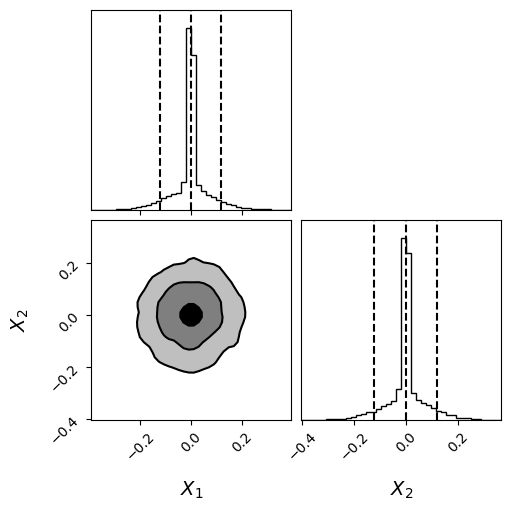

In [5]:

fig = corner.corner(
    posterior_samples[::1,:2], bins=40,labels=[r"$X_{1}$",r"$X_{2}$"],label_kwargs = {"fontsize": 14},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=False,
    fontzise=24,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)

plt.show()

## 7. Estimate ln(Z) with MorphZ

We thin the posterior samples by a factor of 30 to reduce autocorrelation, then pass them — together with the corresponding log-posterior values — to `morphZ.evidence()`.

MorphZ uses the **pair** morph strategy with a Silverman-bandwidth KDE to estimate:
$$
\ln Z = \ln \int \mathcal{L}(\theta)\, p(\theta)\, \mathrm{d}\theta
$$

The analytical result is $\ln Z = \ln 2 \approx 0.6931$.

In [6]:
from mins import CallableModel, MINSampler, MorphProposal, EnsembleRWalkSettings, RWalkSettings
from mins.diagnostics import summarize
from mins.plotting import plot_run, plot_weight_health
from mins import StoppingCriterionConfig, StoppingPolicy

stopping = StoppingPolicy(
    criteria=(
        StoppingCriterionConfig(
            name="live_logz_error",
            tolerance=1e-2,
        ),
        StoppingCriterionConfig(
            name="logz_stability",
            tolerance=1e-2,
        ),
    ),
    mode="all",
    consecutive=2,
    min_iterations=10,
    stability_window=10,
)



param_labels = [f"x{i+1}" for i in range(ndim)]

model = CallableModel(
    ndim=ndim,
    parameter_names=param_labels,
    log_likelihood_fn=lnlikefn,
    log_prior_fn=lnpriorfn,
    vectorized=True,
)
proposal = MorphProposal.fit(
    posterior_samples[::20,:],
    param_names=model.parameter_names,
    morph_type="3_group",
    kde_bw="silverman",
)
mins_sampler = MINSampler(
    model=model,
    importance_morph=proposal,
    proposal_scheme="rwalk",
    n_live=100,
    rng=20260725,
)
# mins_sampler = MINSampler(
#     model=model,
#     importance_morph=proposal,
#     proposal_scheme="en-rwalk",
#         ensemble_rwalk_settings=EnsembleRWalkSettings(
#             n_walkers=6,
#             n_sweeps=4,
#             # gamma=None uses 2.38 / sqrt(2 * ndim)
#         ),
#     n_live=100,
#     rng=20260725,
# )

mins_result = mins_sampler.run(
    dlogz=0.01,
    max_iterations=200_000,
    max_proposals_per_replacement=500_000,
    max_likelihood_calls=10_000_000,
    progress=True
)

TC groups:   0%|          | 0/455 [00:00<?, ?it/s]

MINS nlive=100: 0it [00:00, ?it/s]

In [7]:
diagnostics = summarize(mins_result)

print("MINS success:", mins_result.success)
print("Termination:", mins_result.termination_reason)
print(f"MINS logZ:    {mins_result.logz:.3f} ± {mins_result.logzerr:.3f}")
print(f"Dynesty logZ: {res.logz[-1]:.3f} ± {res.logzerr[-1]:.3f}")
print(f"Reference:    {np.log(2):.3f}")
print("Iterations:", mins_result.niter)
print("Likelihood calls:", mins_result.n_likelihood_calls)
print("Diagnostics:", diagnostics)

for warning in mins_result.warnings:
    print("WARNING:", warning)

MINS success: True
Termination: remaining_evidence
MINS logZ:    1.510 ± 0.275
Dynesty logZ: 1.150 ± 0.204
Reference:    0.693
Iterations: 1650
Likelihood calls: 57850
Diagnostics: RunDiagnostics(posterior_ess=887.1091112758786, relative_posterior_ess=0.5069194921576449, proposal_acceptance_fraction=0.02857142857142857, maximum_proposals_per_replacement=35, thresholds_monotone=True, conservative_log_remaining=-2.4143405328990255, final_remaining_fraction=0.009923047272471919, final_remaining_dlogz=0.009972608846517374, final_live_ess=96.10276820369202, final_live_mean_rse=0.020239164138384214, final_live_logz_error=0.00020083418250050496, final_logz_stability=4.8588247790970485e-05, final_stopping_streak=1)


(10000, 15)


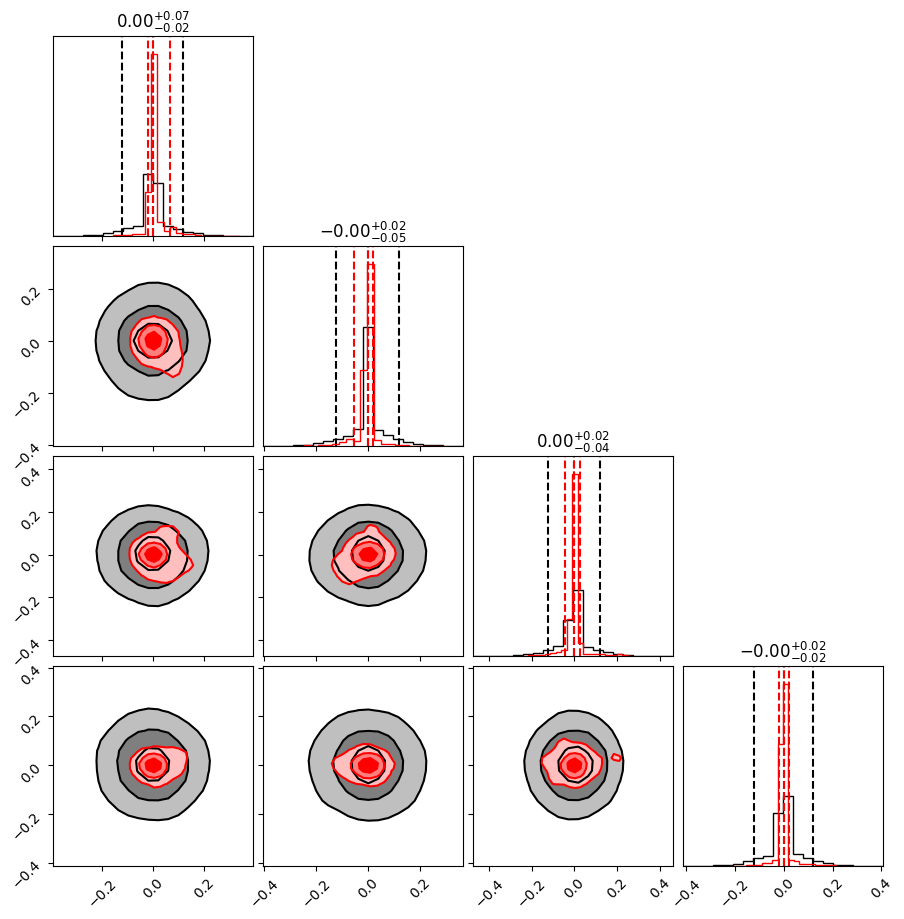

In [8]:
equal_samples = mins_result.resample_equal(
    rng=123,          # required for reproducibility
    n_samples=10000,
)

print(equal_samples.shape)  # (10000, ndim)

fig = corner.corner(
    posterior_samples[::1,:4], bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
corner.corner(
    equal_samples[::2,:4],color="red", bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fig=fig,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
plt.show()